# 🛰️ Project Goal

**Predict whether a given day will be "pleasant" or "unpleasant" for a weather station, based on historical weather data.**

---

## 🔁 Problem Statement

We are given a dataset containing **9 weather metrics** (e.g., temperature, humidity, wind) for **15 weather stations**, recorded **over time**, along with binary labels indicating whether each day was considered **pleasant or unpleasant** per station.
- In our earlier CNN-based approach, we framed this as a **spatial classification problem** — treating each day as a snapshot across all stations. *Even though time existed as part of the data, **the model's perspective** was not temporal.* To explore a sequential framing more suited to RNNs, we now reframe the problem as:

    - > **"Can we predict a station’s future pleasantness using its historical weather over time?"**

This requires transforming the data:

* From a **wide format** (all stations per day)
* To a **long format** (station-by-station over sequences of days)

> We reshape the data so that, instead of each row being “all stations at one time,” it becomes “a sequence of time points for one station.” So the training examples are now like:

    - 📦 Input: A sequence of 15 days of 9 features for Berlin

    - 🎯 Output: Was the weather on day 16 pleasant in Berlin?

Each station becomes its own little universe of past–present–future weather.

---

We are **still** making predictions for all 15 weather stations, but **not all at once** like before. Instead, **each station is treated independently**, and predictions are made **per station across time**.


### 🔄 CNN vs RNN: The Shift

|                  | **CNN (spatial snapshot)**                | **RNN (temporal sequence)**                                                   |
| ---------------- | ----------------------------------------- | ----------------------------------------------------------------------------- |
| **Input**        | One day across 15 stations                | One station across many days                                                  |
| **Prediction**   | 15 binary labels (1 per station, per day) | 1 binary label (for that station, that day)                                   |
| **Structure**    | (batch, 15 stations, 9 features)          | (batch, time\_steps, 9 features)                                              |
| **Output shape** | `(batch_size, 15)`                        | `(batch_size, 1)` or possibly `(batch_size, time_steps)` if sequence labeling |

---



# 1. Import Libraries and Datasets

In [63]:
# 📊 Data manipulation
import pandas as pd
import numpy as np

# 📈 Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# 📁 File operations
import os

# 🔧 Utilities
import operator
from numpy import unique

# 🤖 Deep learning (Keras via TensorFlow)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 📂 Data splitting
from sklearn.model_selection import train_test_split

# 🎲 Reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [64]:
weather_unmelt = pd.read_csv('weather_data_post_unmelt.csv')

In [65]:
pleasant_unmelt = pd.read_csv('pleasant_weather_post_unmelt.csv')

In [66]:
weather_unmelt.head()

,date,date_parsed,year,month,day_name,weatherstation,country,cloud_cover,global_radiation,humidity,precipitation,pressure,snow_depth,sunshine,temp_max,temp_mean,temp_min,wind_speed
0,19600101,1960-01-01,1960,1,Friday,BASEL,Switzerland,7.0,0.32,0.85,0.09,1.0180,0.0,0.7,10.9,6.5,0.8,2.1
1,19600101,1960-01-01,1960,1,Friday,BELGRADE,Serbia,1.0,0.88,0.81,0.00,1.0195,NaN,7.0,7.9,3.7,-0.9,NaN
2,19600101,1960-01-01,1960,1,Friday,BUDAPEST,Hungary,4.0,0.44,0.67,0.01,1.0170,NaN,2.3,5.1,2.4,-0.4,NaN
3,19600101,1960-01-01,1960,1,Friday,DEBILT,Netherlands,7.0,0.07,0.85,0.25,1.0032,NaN,0.0,11.0,9.3,7.4,7.7
4,19600101,1960-01-01,1960,1,Friday,DUSSELDORF,Germany,8.0,0.12,0.83,0.08,1.0161,0.0,0.0,11.5,10.0,7.0,5.4


In [67]:
pleasant_unmelt.head()

,date,date_parsed,year,day_name,weatherstation,country,weatherstation_country,pleasant_weather
0,19600101,1960-01-01,1960,Friday,BASEL,Switzerland,BASEL_Switzerland,False
1,19600101,1960-01-01,1960,Friday,BELGRADE,Serbia,BELGRADE_Serbia,False
2,19600101,1960-01-01,1960,Friday,BUDAPEST,Hungary,BUDAPEST_Hungary,False
3,19600101,1960-01-01,1960,Friday,DEBILT,Netherlands,DEBILT_Netherlands,False
4,19600101,1960-01-01,1960,Friday,DUSSELDORF,Germany,DUSSELDORF_Germany,False


# 2. Feature Selection & Label Prep

## 🧩 Merge Strategy
> We use an inner join between pleasant_unmelt and weather_unmelt so that only rows with matching date and weatherstation in both datasets are preserved. This removes any rows that are missing from either dataset — such as stations without labels or dates that don’t align.

In [68]:
merged_df = pd.merge(
    weather_unmelt,
    pleasant_unmelt,
    on=["date", "weatherstation"],
    how="inner"
)

In [69]:
merged_df.shape

(344250, 24)

In [70]:
merged_df.head()

,date,date_parsed_x,year_x,month,day_name_x,weatherstation,country_x,cloud_cover,global_radiation,humidity,...,temp_max,temp_mean,temp_min,wind_speed,date_parsed_y,year_y,day_name_y,country_y,weatherstation_country,pleasant_weather
0,19600101,1960-01-01,1960,1,Friday,BASEL,Switzerland,7.0,0.32,0.85,...,10.9,6.5,0.8,2.1,1960-01-01,1960,Friday,Switzerland,BASEL_Switzerland,False
1,19600101,1960-01-01,1960,1,Friday,BELGRADE,Serbia,1.0,0.88,0.81,...,7.9,3.7,-0.9,NaN,1960-01-01,1960,Friday,Serbia,BELGRADE_Serbia,False
2,19600101,1960-01-01,1960,1,Friday,BUDAPEST,Hungary,4.0,0.44,0.67,...,5.1,2.4,-0.4,NaN,1960-01-01,1960,Friday,Hungary,BUDAPEST_Hungary,False
3,19600101,1960-01-01,1960,1,Friday,DEBILT,Netherlands,7.0,0.07,0.85,...,11.0,9.3,7.4,7.7,1960-01-01,1960,Friday,Netherlands,DEBILT_Netherlands,False
4,19600101,1960-01-01,1960,1,Friday,DUSSELDORF,Germany,8.0,0.12,0.83,...,11.5,10.0,7.0,5.4,1960-01-01,1960,Friday,Germany,DUSSELDORF_Germany,False


In [71]:
list(merged_df.columns)

['date',
 'date_parsed_x',
 'year_x',
 'month',
 'day_name_x',
 'weatherstation',
 'country_x',
 'cloud_cover',
 'global_radiation',
 'humidity',
 'precipitation',
 'pressure',
 'snow_depth',
 'sunshine',
 'temp_max',
 'temp_mean',
 'temp_min',
 'wind_speed',
 'date_parsed_y',
 'year_y',
 'day_name_y',
 'country_y',
 'weatherstation_country',
 'pleasant_weather']

## 🧽 Clean the Dataframe
After merging, we dropped duplicate columns introduced during the join (e.g., *_y versions of date_parsed, year, etc.), and removed features with excessive missing values like snow_depth and wind_speed. We also renamed *_x columns to their original names for clarity.

In [72]:
merged_df = merged_df.drop(columns=[
    'date_parsed_y',
    'year_y',
    'day_name_y',
    'country_y',
    'year_x',
    'day_name_x',
    'date',
    'country_x',
    'weatherstation_country',
    'month'
])

merged_df = merged_df.rename(columns={
    'date_parsed_x': 'date_parsed',
    'country_x': 'country'
})


In [73]:
merged_df = merged_df.drop(columns=['snow_depth', 'wind_speed'])


In [74]:
merged_df.loc[merged_df['weatherstation'] == 'KASSEL', 'cloud_cover'] = \
    merged_df.loc[merged_df['weatherstation'] == 'LJUBLJANA', 'cloud_cover'].values

merged_df.loc[merged_df['weatherstation'] == 'MUNCHENB', 'pressure'] = \
    merged_df.loc[merged_df['weatherstation'] == 'SONNBLICK', 'pressure'].values

merged_df.loc[merged_df['weatherstation'] == 'STOCKHOLM', 'humidity'] = \
    merged_df.loc[merged_df['weatherstation'] == 'OSLO', 'humidity'].values


In [75]:
merged_df.head()

,date_parsed,weatherstation,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min,pleasant_weather
0,1960-01-01,BASEL,7.0,0.32,0.85,0.09,1.0180,0.7,10.9,6.5,0.8,False
1,1960-01-01,BELGRADE,1.0,0.88,0.81,0.00,1.0195,7.0,7.9,3.7,-0.9,False
2,1960-01-01,BUDAPEST,4.0,0.44,0.67,0.01,1.0170,2.3,5.1,2.4,-0.4,False
3,1960-01-01,DEBILT,7.0,0.07,0.85,0.25,1.0032,0.0,11.0,9.3,7.4,False
4,1960-01-01,DUSSELDORF,8.0,0.12,0.83,0.08,1.0161,0.0,11.5,10.0,7.0,False


In [76]:
# Define your features for the model
feature_cols = ['cloud_cover', 'global_radiation', 'humidity', 'precipitation',
                'pressure', 'sunshine', 'temp_max', 'temp_mean', 'temp_min']

# Convert pleasant_weather bool to int (False → 0, True → 1)
merged_df['pleasant_weather'] = merged_df['pleasant_weather'].astype(int)


In [77]:
# Export to CSV
merged_df.to_csv('weather_pleasant_merged_cleaned.csv', index=False)


# 3. Sort & Slide: Build the Sequence for RNN

💬 “For every day I can fit a full sequence, I grab that sequence of weather data, and I save the answer (pleasant/unpleasant) for the day right after. I repeat that until I run out of space.”

#### What this code does:
- Loops through each weather station’s data
- Creates sliding windows of 7 days of weather data
- Uses the label of the 8th day as the prediction target
- Collects all sequences and targets into arrays X (inputs) and y (labels)

In [78]:
sequence_length = 7  # Number of days the model will "look back"
X = []
y = []

# Loop through each unique weather station
# For each, we'll build sequences of 7 days of weather data and the label for the following day
for station in merged_df['weatherstation'].unique():
    # Create a mini-dataframe with only this station's data
    df_station = merged_df[merged_df['weatherstation'] == station]

    # Extract the features and labels as NumPy arrays
    features = df_station[feature_cols].values
    labels = df_station['pleasant_weather'].values

    # Slide a window of size `sequence_length` over the data
    # For each position, grab the sequence and the label of the *next* day
    for i in range(len(df_station) - sequence_length):
        X.append(features[i:i + sequence_length])          # Input: 7 consecutive days of features
        y.append(labels[i + sequence_length])              # Target: pleasant/unpleasant label for the day after

# Convert the final lists into NumPy arrays for model input
X = np.array(X)
y = np.array(y)


# 4. Data Preparation: Temporal Train-Test Split & Feature Scaling

| Step                        | Technical Term                              |
| --------------------------- | ------------------------------------------- |
| Splitting without shuffle   | **Temporal Train-Test Split**               |
| Scaling using training data | **Feature Normalization / Standardization** |
| Reshape to 3D (for RNN)     | **Reshaping to RNN-Compatible Input Shape** |


In [79]:
### Split
# Split WITHOUT shuffling — preserve temporal order
split_index = int(len(X) * 0.8)  # 80% train, 20% test

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]


In [80]:
### Scale
from sklearn.preprocessing import StandardScaler

# Reshape to 2D (samples × features) to fit the scaler
X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d = X_test.reshape(-1, X_test.shape[2])

# Fit the scaler on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_2d)

# Use the same scaler for test data
X_test_scaled = scaler.transform(X_test_2d)

# Reshape back to 3D (samples × timesteps × features)
X_train_scaled = X_train_scaled.reshape(X_train.shape)
X_test_scaled = X_test_scaled.reshape(X_test.shape)


# 5. Model Building & RNN Architecture

In [81]:
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import LSTM, Dense, Dropout

v1_model = Sequential()
# Long Short-term Memory; 64 memory units; expecting inputs of X time-steps with Y features
v1_model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
# For regularization / not overfitting, turn of %30 of neurons during learning
v1_model.add(Dropout(0.3))
# Relu to deal with vanishing gradients
v1_model.add(Dense(32, activation='relu'))
v1_model.add(Dense(1, activation='sigmoid'))  # Binary classification#


In [82]:
### Compile

v1_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


In [83]:
### Fit the model
v1_history = v1_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 68s 7ms/step - accuracy: 0.8272 - loss: 0.3351 - val_accuracy: 0.9443 - val_loss: 0.1210
Epoch 2/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 65s 8ms/step - accuracy: 0.8402 - loss: 0.3161 - val_accuracy: 0.9451 - val_loss: 0.1202
Epoch 3/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 87s 8ms/step - accuracy: 0.8414 - loss: 0.3133 - val_accuracy: 0.9447 - val_loss: 0.1211
Epoch 4/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 67s 8ms/step - accuracy: 0.8427 - loss: 0.3115 - val_accuracy: 0.9457 - val_loss: 0.1200
Epoch 5/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 79s 7ms/step - accuracy: 0.8437 - loss: 0.3104 - val_accuracy: 0.9450 - val_loss: 0.1204
Epoch 6/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 62s 7ms/step - accuracy: 0.8450 - loss: 0.3093 - val_accuracy: 0.9450 - val_loss: 0.1212
Epoch 7/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 65s 8ms/step - accuracy: 0.8444 - loss: 0.3088 - val_accuracy: 0.9451 - val_loss: 0.1206
Epoch 8/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 66s 8ms/step - accuracy: 0.8450 - loss: 0

# 6. Evaluation

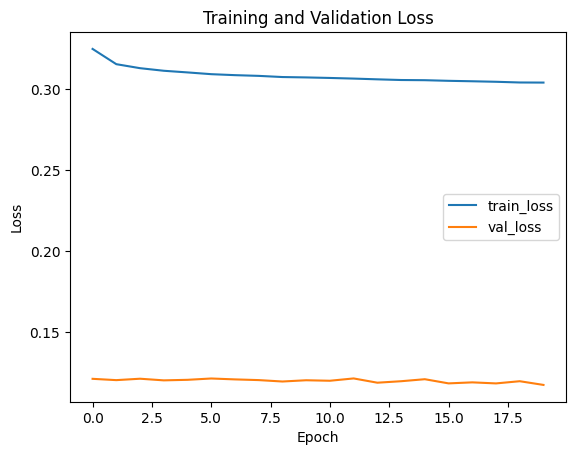

In [84]:
import matplotlib.pyplot as plt

plt.plot(v1_history.history['loss'], label='train_loss')
plt.plot(v1_history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


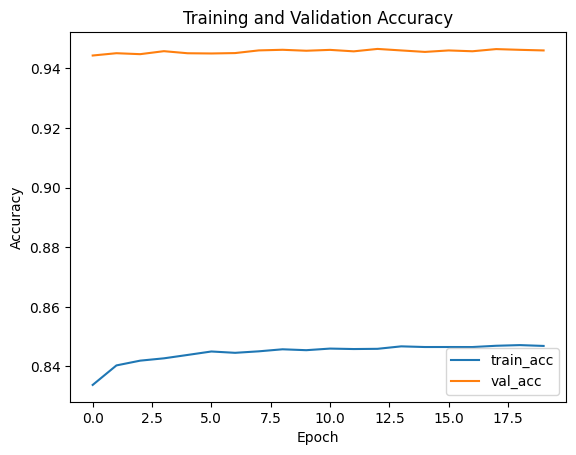

In [86]:
plt.plot(v1_history.history['accuracy'], label='train_acc')
plt.plot(v1_history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()


In [87]:
test_loss, test_acc = v1_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Test Loss: 0.1172
Test Accuracy: 0.9460


#### ⚠️ Accuracy/Confusion Matrix Notes:
Since class 1 is only ~7% of the data, it's imbalanced, so accuracy alone is misleading.

Confusion Matrix shows 43% if minority class guesses were false guesses.

In [88]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = v1_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Assuming binary classification

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


2151/2151 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     63761
           1       0.65      0.57      0.61      5068

    accuracy                           0.95     68829
   macro avg       0.81      0.78      0.79     68829
weighted avg       0.94      0.95      0.94     68829

Confusion Matrix:
 [[62199  1562]
 [ 2156  2912]]


### 💡 And about ROC / AUC:

* **ROC Curve** plots:

  * **True Positive Rate (Recall)** vs. **False Positive Rate**
* **AUC (Area Under the Curve)**:

  * Score from 0–1
  * 1.0 = perfect classifier
  * 0.5 = random guessing

---

#### ⚠️ ROC Notes:

🚦 So What Does AUC = 0.97 Mean Here?
- That your model is very capable of distinguishing "pleasant" vs "unpleasant" — even though...
    - the recall and F1-score for the minority class were bad 😓

> That tells us:
- 🎯 The problem isn’t the model’s learning...
- 😬 The problem is the threshold used to decide "1" vs "0" (default is 0.5).

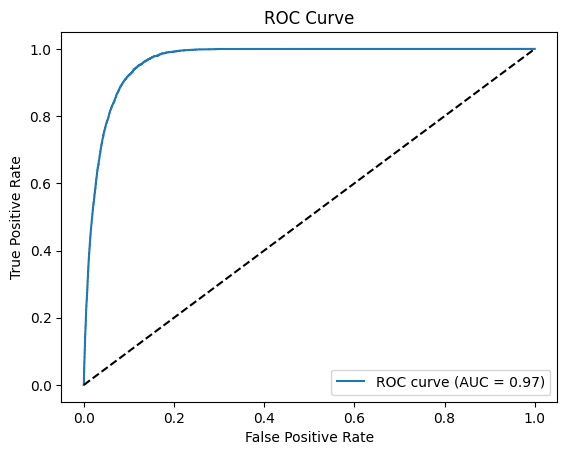

In [89]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# 7. Play with Predictions (no need to re-train)

In [90]:
from sklearn.metrics import roc_curve

# Predict probabilities (not class labels!)
y_probs = v1_model.predict(X_test)

# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Let’s find a threshold that gives you better recall
# For example, if we want to favor recall > 0.75
import numpy as np
target_recall = 0.75
best_thresh = thresholds[np.argmax(tpr >= target_recall)]


2151/2151 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


In [91]:
y_pred_adjusted = (y_probs >= best_thresh).astype(int)


In [92]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = v1_model.predict(X_test)

print(classification_report(y_test, y_pred_adjusted))
cm = confusion_matrix(y_test, y_pred_adjusted)
print("Confusion Matrix:\n", cm)


2151/2151 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     63761
           1       0.57      0.75      0.65      5068

    accuracy                           0.94     68829
   macro avg       0.78      0.85      0.81     68829
weighted avg       0.95      0.94      0.94     68829

Confusion Matrix:
 [[60918  2843]
 [ 1267  3801]]


### 🔍 Let’s look at the actual shift:

#### Previous (threshold 0.5):

* **Precision (class 1):** 0.65
* **Recall (class 1):** 0.57
* **F1-score (class 1):** 0.61

#### After threshold tuning:

* **Precision (class 1):** 0.57
* **Recall (class 1):** 0.75
* **F1-score (class 1):** 0.65 ✅

---

### 💡 What improved?

* ✅ **Recall jumped** → the model is *catching more* of the actual 1s (pleasant days).
* ➖ **Precision dropped** → it’s also making *a few more mistakes* (predicting pleasant when it wasn’t).

But your **F1-score (which balances both)** went **up** — and that’s a great signal.

---

### 🧠 Why this matters:

* You didn’t touch the model.
* You didn’t retrain or reprocess.
* You just **listened better** to what it was already trying to tell you!
  * You had an **AUC of 0.97** → 🚀 your model *knows what's up*, you just needed to ask it the right question.

This is **the art of threshold tuning**.

---

# 8. CONCLUSION

Because CNNs capture patterns across multiple weather features within a single day, they’re well-suited to ClimateWins’ goal of tracking how the definition of “pleasant weather” shifts over time. For forecasting applications like early warning systems, however, a time-aware model like an RNN is more appropriate, as it can learn from sequences of days to anticipate what comes next.